In [0]:
# ============================================
# MACHINE LEARNING: Sales Forecasting
# ============================================

print("🤖 MACHINE LEARNING MODELS")
print("=" * 50)

# Load monthly summary for forecasting
monthly_spark = spark.table("retail_lakehouse.gold_monthly_summary") \
    .orderBy("Year", "Month")

# Convert to Pandas for ML
monthly_pdf = monthly_spark.toPandas()

print(f"📊 Loaded {len(monthly_pdf)} months of data")
print("\n📅 Monthly Revenue Data:")
print(monthly_pdf[['Year', 'Month', 'Monthly_Revenue']].to_string(index=False))

🤖 MACHINE LEARNING MODELS
📊 Loaded 13 months of data

📅 Monthly Revenue Data:
 Year  Month  Monthly_Revenue
 2010     12        570422.73
 2011      1        568101.31
 2011      2        446084.92
 2011      3        594081.76
 2011      4        468374.33
 2011      5        677355.15
 2011      6        660046.05
 2011      7        598962.90
 2011      8        644051.04
 2011      9        950690.20
 2011     10       1035642.45
 2011     11       1156205.61
 2011     12        517190.44


📈 REVENUE TREND VISUALIZATION


/home/spark-5abee55c-cc22-4e57-9673-d6/.ipykernel/12886/command-7281802692684184-1514144544:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


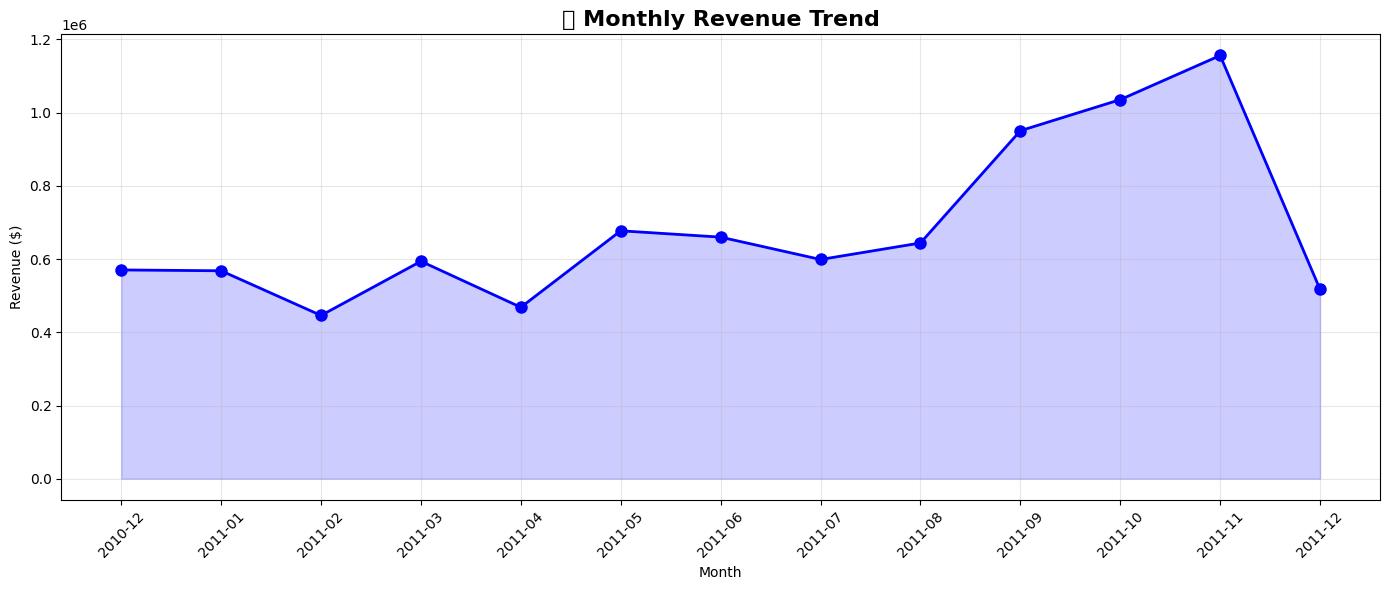

💡 Revenue range: $446,085 - $1,156,206


In [0]:
import matplotlib.pyplot as plt
import numpy as np

print("📈 REVENUE TREND VISUALIZATION")
print("=" * 50)

# Create month labels
monthly_pdf['Label'] = monthly_pdf['Year'].astype(str) + '-' + \
                        monthly_pdf['Month'].astype(str).str.zfill(2)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_pdf['Label'], monthly_pdf['Monthly_Revenue'], 
         marker='o', linewidth=2, color='blue', markersize=8)
plt.fill_between(range(len(monthly_pdf)), monthly_pdf['Monthly_Revenue'], 
                 alpha=0.2, color='blue')
plt.title('📈 Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"💡 Revenue range: ${monthly_pdf['Monthly_Revenue'].min():,.0f} - ${monthly_pdf['Monthly_Revenue'].max():,.0f}")

📊 METHOD 1: Moving Average Forecast
🔮 Forecast for Next Month:
   Based on last 3 months: $903,012.83
   Based on last 6 months: $817,123.77


/home/spark-5abee55c-cc22-4e57-9673-d6/.ipykernel/12886/command-7281802692684185-1416045027:30: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


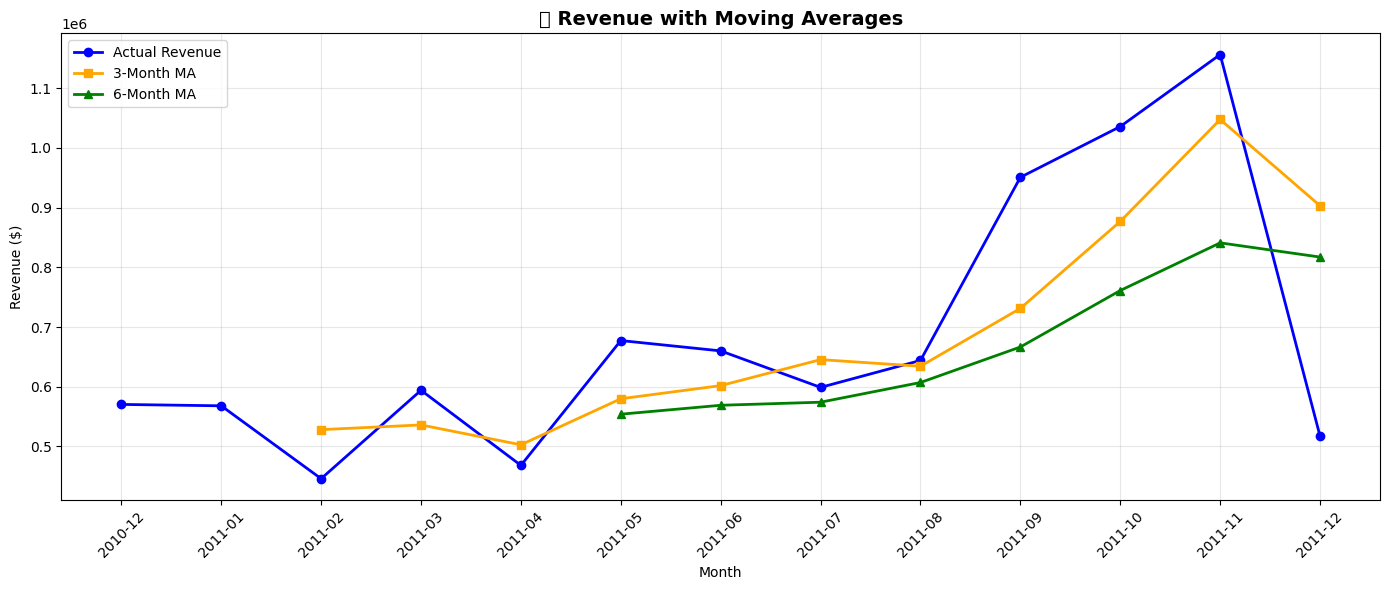

In [0]:
print("📊 METHOD 1: Moving Average Forecast")
print("=" * 50)

# Calculate moving averages
monthly_pdf['MA_3'] = monthly_pdf['Monthly_Revenue'].rolling(window=3).mean()
monthly_pdf['MA_6'] = monthly_pdf['Monthly_Revenue'].rolling(window=6).mean()

# Forecast next month (average of last 3 months)
last_3_avg = monthly_pdf['Monthly_Revenue'].tail(3).mean()
last_6_avg = monthly_pdf['Monthly_Revenue'].tail(6).mean()

print(f"🔮 Forecast for Next Month:")
print(f"   Based on last 3 months: ${last_3_avg:,.2f}")
print(f"   Based on last 6 months: ${last_6_avg:,.2f}")

# Plot with moving averages
plt.figure(figsize=(14, 6))
plt.plot(monthly_pdf['Label'], monthly_pdf['Monthly_Revenue'], 
         marker='o', label='Actual Revenue', linewidth=2, color='blue')
plt.plot(monthly_pdf['Label'], monthly_pdf['MA_3'], 
         marker='s', label='3-Month MA', linewidth=2, color='orange')
plt.plot(monthly_pdf['Label'], monthly_pdf['MA_6'], 
         marker='^', label='6-Month MA', linewidth=2, color='green')
plt.title('📈 Revenue with Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📊 METHOD 2: Linear Regression Forecast
🔮 Linear Regression Predictions:
   Month +1: $926,790.85
   Month +2: $961,527.91
   Month +3: $996,264.97

📊 Model R-squared: 0.3706
   (1.0 = perfect fit, closer to 1 is better)


/home/spark-5abee55c-cc22-4e57-9673-d6/.ipykernel/12886/command-7281802692684186-3642788847:48: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


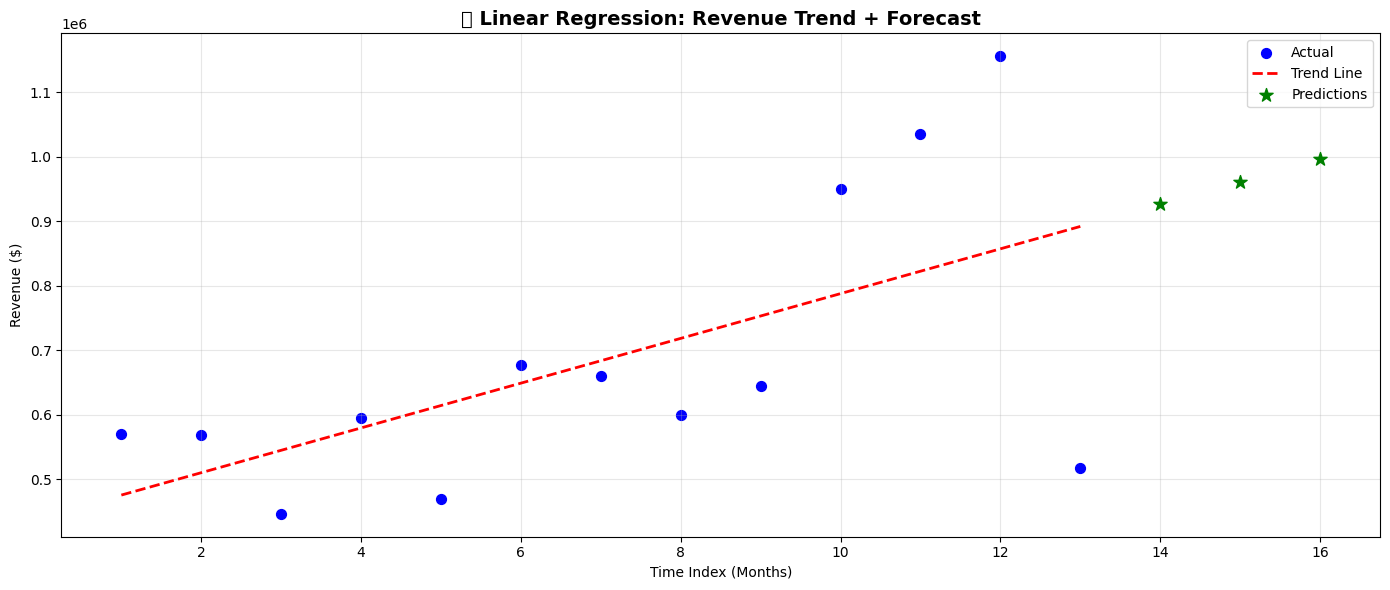

In [0]:
from sklearn.linear_model import LinearRegression

print("📊 METHOD 2: Linear Regression Forecast")
print("=" * 50)

# Prepare data
monthly_pdf['Time_Index'] = range(1, len(monthly_pdf) + 1)

X = monthly_pdf[['Time_Index']].values
y = monthly_pdf['Monthly_Revenue'].values

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 3 months
future_index = np.array([[len(monthly_pdf) + 1], 
                         [len(monthly_pdf) + 2], 
                         [len(monthly_pdf) + 3]])
predictions = model.predict(future_index)

print("🔮 Linear Regression Predictions:")
for i, pred in enumerate(predictions, 1):
    print(f"   Month +{i}: ${pred:,.2f}")

# Model accuracy
r_squared = model.score(X, y)
print(f"\n📊 Model R-squared: {r_squared:.4f}")
print(f"   (1.0 = perfect fit, closer to 1 is better)")

# Plot trend line
plt.figure(figsize=(14, 6))
plt.scatter(monthly_pdf['Time_Index'], monthly_pdf['Monthly_Revenue'], 
           color='blue', s=50, label='Actual')
plt.plot(monthly_pdf['Time_Index'], model.predict(X), 
         color='red', linewidth=2, linestyle='--', label='Trend Line')

# Add predictions
future_x = [len(monthly_pdf) + 1, len(monthly_pdf) + 2, len(monthly_pdf) + 3]
plt.scatter(future_x, predictions, color='green', s=100, marker='*', 
           label='Predictions', zorder=5)

plt.title('📈 Linear Regression: Revenue Trend + Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Time Index (Months)')
plt.ylabel('Revenue ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [0]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("👥 CUSTOMER SEGMENTATION")
print("=" * 50)

# Load customer data
customer_pdf = spark.table("retail_lakehouse.gold_customer_analysis").toPandas()
print(f"📊 {len(customer_pdf):,} customers to segment")

# Select features for clustering
features = ['Total_Spent', 'Total_Orders', 'Total_Items_Bought', 'Unique_Products_Bought']
X_cluster = customer_pdf[features].copy()

# Scale features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means (4 segments)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_pdf['Segment'] = kmeans.fit_predict(X_scaled)

# Analyze each segment
print("\n📊 Segment Analysis:")
for seg in sorted(customer_pdf['Segment'].unique()):
    seg_data = customer_pdf[customer_pdf['Segment'] == seg]
    print(f"\nSegment {seg}:")
    print(f"  Customers: {len(seg_data):,}")
    print(f"  Avg Spending: ${seg_data['Total_Spent'].mean():,.2f}")
    print(f"  Avg Orders: {seg_data['Total_Orders'].mean():.1f}")
    print(f"  Avg Items: {seg_data['Total_Items_Bought'].mean():.1f}")
    print(f"  Total Revenue: ${seg_data['Total_Spent'].sum():,.2f}")

👥 CUSTOMER SEGMENTATION
📊 4,338 customers to segment

📊 Segment Analysis:

Segment 0:
  Customers: 3,713
  Avg Spending: $879.38
  Avg Orders: 2.6
  Avg Items: 523.1
  Total Revenue: $3,265,149.96

Segment 1:
  Customers: 11
  Avg Spending: $138,694.66
  Avg Orders: 39.1
  Avg Items: 76326.4
  Total Revenue: $1,525,641.22

Segment 2:
  Customers: 8
  Avg Spending: $58,180.91
  Avg Orders: 109.5
  Avg Items: 34801.9
  Total Revenue: $465,447.27

Segment 3:
  Customers: 606
  Avg Spending: $5,991.70
  Avg Orders: 12.4
  Avg Items: 3451.6
  Total Revenue: $3,630,970.44


/home/spark-5abee55c-cc22-4e57-9673-d6/.ipykernel/12886/command-7281802692684188-2714656081:23: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


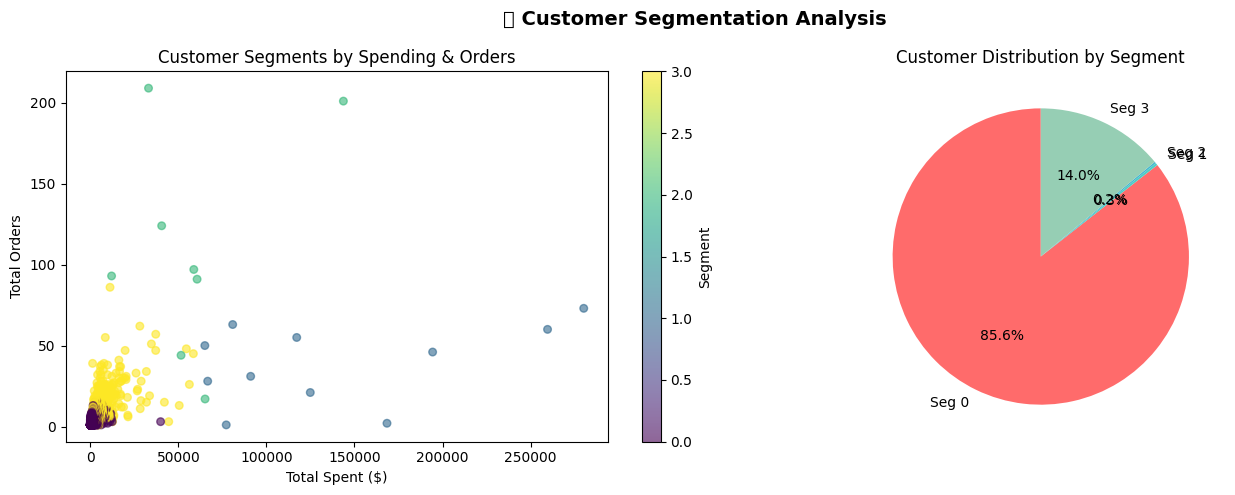

In [0]:
# Plot segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
scatter = axes[0].scatter(customer_pdf['Total_Spent'], 
                         customer_pdf['Total_Orders'],
                         c=customer_pdf['Segment'], 
                         cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel('Total Spent ($)')
axes[0].set_ylabel('Total Orders')
axes[0].set_title('Customer Segments by Spending & Orders')
plt.colorbar(scatter, ax=axes[0], label='Segment')

# Pie chart of segment sizes
segment_sizes = customer_pdf['Segment'].value_counts().sort_index()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
axes[1].pie(segment_sizes.values, 
           labels=[f'Seg {i}' for i in segment_sizes.index],
           autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Customer Distribution by Segment')

plt.suptitle('👥 Customer Segmentation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

💰 REVENUE BY SEGMENT
         Customer_Count  Total_Revenue  Avg_Spending  Revenue_Share
Segment                                                            
0                  3713     3265149.96        879.38           36.7
1                    11     1525641.22     138694.66           17.2
2                     8      465447.27      58180.91            5.2
3                   606     3630970.44       5991.70           40.9


/home/spark-5abee55c-cc22-4e57-9673-d6/.ipykernel/12886/command-7281802692684189-4057442339:25: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/databricks/python/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


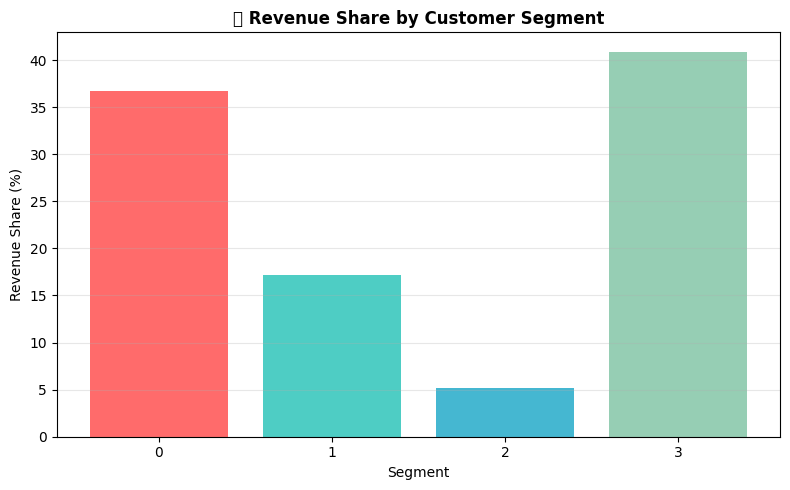

In [0]:
# Revenue contribution by segment
print("💰 REVENUE BY SEGMENT")
print("=" * 50)

seg_revenue = customer_pdf.groupby('Segment').agg({
    'CustomerID': 'count',
    'Total_Spent': ['sum', 'mean']
}).round(2)

seg_revenue.columns = ['Customer_Count', 'Total_Revenue', 'Avg_Spending']
seg_revenue['Revenue_Share'] = (seg_revenue['Total_Revenue'] / 
                                 seg_revenue['Total_Revenue'].sum() * 100).round(1)

print(seg_revenue)

# Plot revenue share
plt.figure(figsize=(8, 5))
plt.bar(seg_revenue.index, seg_revenue['Revenue_Share'], 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.xlabel('Segment')
plt.ylabel('Revenue Share (%)')
plt.title('💰 Revenue Share by Customer Segment', fontweight='bold')
plt.xticks(seg_revenue.index)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [0]:
print("🎯 HIGH-VALUE CUSTOMER INDICATORS")
print("=" * 50)

# Define high-value (top 20% spenders)
threshold = customer_pdf['Total_Spent'].quantile(0.80)
customer_pdf['High_Value'] = (customer_pdf['Total_Spent'] >= threshold).astype(int)

high_value = customer_pdf[customer_pdf['High_Value'] == 1]
regular = customer_pdf[customer_pdf['High_Value'] == 0]

print(f"High-Value Threshold: ${threshold:,.2f}")
print(f"High-Value Customers: {len(high_value):,} ({len(high_value)/len(customer_pdf)*100:.1f}%)")
print(f"Regular Customers: {len(regular):,} ({len(regular)/len(customer_pdf)*100:.1f}%)")

print("\n📊 High-Value vs Regular Customers:")
print(f"                    High-Value    Regular")
print(f"  Avg Spending:     ${high_value['Total_Spent'].mean():,.2f}      ${regular['Total_Spent'].mean():,.2f}")
print(f"  Avg Orders:       {high_value['Total_Orders'].mean():.1f}            {regular['Total_Orders'].mean():.1f}")
print(f"  Avg Items:        {high_value['Total_Items_Bought'].mean():.1f}           {regular['Total_Items_Bought'].mean():.1f}")
print(f"  Avg Unique Prods: {high_value['Unique_Products_Bought'].mean():.1f}            {regular['Unique_Products_Bought'].mean():.1f}")

🎯 HIGH-VALUE CUSTOMER INDICATORS
High-Value Threshold: $2,055.05
High-Value Customers: 868 (20.0%)
Regular Customers: 3,470 (80.0%)

📊 High-Value vs Regular Customers:
                    High-Value    Regular
  Avg Spending:     $7,646.66      $648.39
  Avg Orders:       11.7            2.4
  Avg Items:        4337.6           399.7
  Avg Unique Prods: 146.6            40.2


In [0]:
print("💾 SAVING SEGMENTED DATA")
print("=" * 50)

# Convert back to Spark and save
segmented_spark = spark.createDataFrame(customer_pdf)

segmented_spark.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("retail_lakehouse.gold_customer_segments")

print("✅ gold_customer_segments table saved!")
print(f"📊 {segmented_spark.count():,} customers with segment labels")

💾 SAVING SEGMENTED DATA
✅ gold_customer_segments table saved!
📊 4,338 customers with segment labels


In [0]:
print("=" * 50)
print("🎉 MACHINE LEARNING COMPLETE!")
print("=" * 50)
print()
print("📊 MODELS BUILT:")
print()
print("1. 📈 Sales Forecasting:")
print(f"   • Moving Average: Next month ≈ ${last_3_avg:,.2f}")
print(f"   • Linear Regression R²: {r_squared:.4f}")
print(f"   • 3-Month Forecast: ${predictions[0]:,.2f}, ${predictions[1]:,.2f}, ${predictions[2]:,.2f}")
print()
print("2. 👥 Customer Segmentation (K-Means):")
for seg in sorted(customer_pdf['Segment'].unique()):
    cnt = len(customer_pdf[customer_pdf['Segment'] == seg])
    avg = customer_pdf[customer_pdf['Segment'] == seg]['Total_Spent'].mean()
    print(f"   • Segment {seg}: {cnt:,} customers, Avg ${avg:,.2f}")
print()
print("3. 🎯 High-Value Predictors:")
print(f"   • {len(high_value):,} high-value customers identified")
print(f"   • Key traits: High orders, diverse products")
print()
print("📁 Next: 06_dashboard")
print("=" * 50)

🎉 MACHINE LEARNING COMPLETE!

📊 MODELS BUILT:

1. 📈 Sales Forecasting:
   • Moving Average: Next month ≈ $903,012.83
   • Linear Regression R²: 0.3706
   • 3-Month Forecast: $926,790.85, $961,527.91, $996,264.97

2. 👥 Customer Segmentation (K-Means):
   • Segment 0: 3,713 customers, Avg $879.38
   • Segment 1: 11 customers, Avg $138,694.66
   • Segment 2: 8 customers, Avg $58,180.91
   • Segment 3: 606 customers, Avg $5,991.70

3. 🎯 High-Value Predictors:
   • 868 high-value customers identified
   • Key traits: High orders, diverse products

📁 Next: 06_dashboard
